# Predictive Maintenance — AutoML-Benchmark mit PyCaret
### Projektarbeit ML · Erweiterung v6 · Alexander Sagert · Juni 2026

> **Companion zum Haupt-Notebook** `14-...`. Stellt die Frage: *Wie gut schlägt sich eine
> automatische ML-Pipeline (PyCaret) gegen unser handgebautes, mit Optuna getuntes XGBoost?*

## Wichtiger Hinweis zur Umgebung
PyCaret 3.3 verlangt **ältere** Paketversionen (numpy < 2, pandas < 3, sklearn < 1.5) und würde
die Projekt-Umgebung beschädigen. Der Benchmark lief daher in einer **isolierten** venv
(`.venv_pycaret`); dieses Notebook liest nur das **exportierte Leaderboard**
(`pycaret_results/leaderboard.csv`) und braucht PyCaret selbst nicht.

**Was PyCaret gemacht hat:** Aus den Rohdaten (Typ + 5 Sensoren) automatisch vorverarbeitet,
SMOTE gegen die Unwucht, dann **~15 Modelle** per 5-facher Cross-Validation verglichen.


## 0 · Leaderboard laden

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")


def _resolve(name):
    here = Path.cwd()
    for c in [here / name, here / "pycaret_results" / name, here.parent / name]:
        if c.exists():
            return c
    hits = list(here.glob(f"**/{name}"))
    if hits:
        return hits[0]
    raise FileNotFoundError(name)


lb = pd.read_csv(_resolve("leaderboard.csv"), index_col=0)
lb = lb.sort_values("AUC", ascending=False)
print("PyCaret-Leaderboard (sortiert nach AUC, 5-fach-CV):")
lb[["Model", "Accuracy", "AUC", "Recall", "Prec.", "F1"]]

PyCaret-Leaderboard (sortiert nach AUC, 5-fach-CV):


,Model,Accuracy,AUC,Recall,Prec.,F1
lightgbm,Light Gradient Boosting Machine,0.9730,0.9660,0.7638,0.5792,0.6579
gbc,Gradient Boosting Classifier,0.9466,0.9644,0.8340,0.3753,0.5165
rf,Random Forest Classifier,0.9662,0.9577,0.6387,0.5037,0.5626
ada,Ada Boost Classifier,0.9351,0.9520,0.7862,0.3195,0.4532
et,Extra Trees Classifier,0.9704,0.9474,0.5868,0.5616,0.5734
ridge,Ridge Classifier,0.8271,0.8971,0.8048,0.1413,0.2403
lda,Linear Discriminant Analysis,0.8271,0.8971,0.8048,0.1413,0.2403
lr,Logistic Regression,0.8258,0.8960,0.8048,0.1402,0.2387
svm,SVM - Linear Kernel,0.8034,0.8683,0.6187,0.2709,0.3024
knn,K Neighbors Classifier,0.8906,0.8497,0.6824,0.1901,0.2971


## 1 · Das Leaderboard visuell — Boosting dominiert
PyCaret kommt unabhängig zu **derselben** Erkenntnis wie unser Projekt: Die **Gradient-Boosting-
Familie** (LightGBM, Gradient Boosting, AdaBoost) liegt vorn, gefolgt von den Bagging-Verfahren
(Random Forest, Extra Trees).

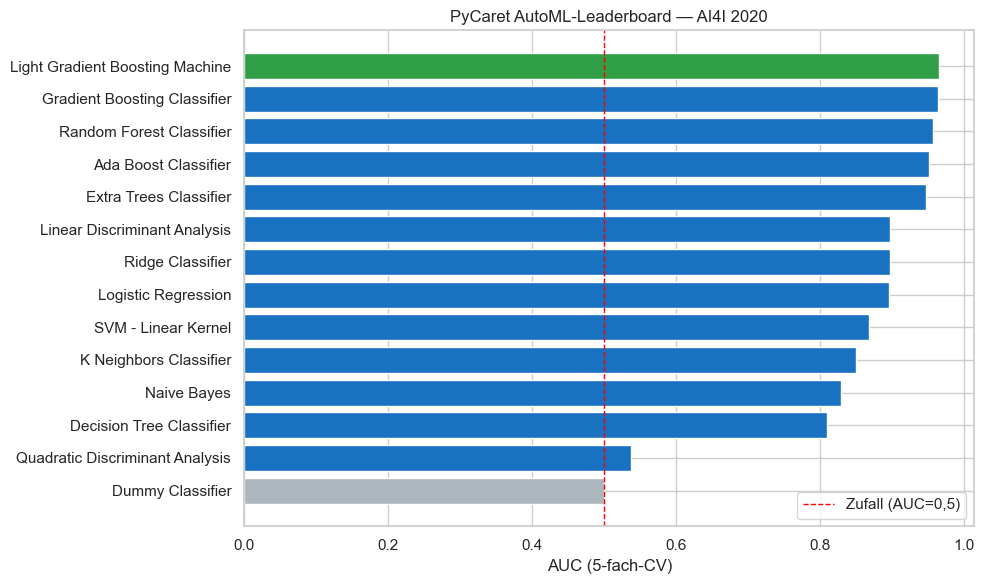

In [2]:
order = lb.sort_values("AUC")
colors = ["#2f9e44" if m == "Light Gradient Boosting Machine"
          else ("#adb5bd" if m == "Dummy Classifier" else "#1971c2")
          for m in order["Model"]]
plt.figure(figsize=(10, 6))
plt.barh(order["Model"], order["AUC"], color=colors)
plt.axvline(0.5, color="red", ls="--", lw=1, label="Zufall (AUC=0,5)")
plt.xlabel("AUC (5-fach-CV)"); plt.title("PyCaret AutoML-Leaderboard — AI4I 2020")
plt.legend(); plt.tight_layout()
plt.savefig(_resolve("leaderboard.csv").parent.parent / "visualisierung" / "14_pycaret_leaderboard.png",
            dpi=130, bbox_inches="tight")
plt.show()

## 2 · Die wichtigste Lektion steckt ganz unten: der Dummy-Classifier
Schau auf die letzte Zeile des Leaderboards:

In [3]:
dummy = lb[lb["Model"] == "Dummy Classifier"][["Accuracy", "AUC", "Recall", "F1"]]
print(dummy.to_string())
print()
print("Ein Modell, das IMMER 'kein Ausfall' sagt, erreicht:")
print(f"  Accuracy: {dummy['Accuracy'].iloc[0]:.1%}  <- sieht super aus!")
print(f"  AUC     : {dummy['AUC'].iloc[0]:.2f}        <- reiner Zufall")
print(f"  Recall  : {dummy['Recall'].iloc[0]:.0%}         <- findet KEINEN einzigen Ausfall")

       Accuracy  AUC  Recall   F1
dummy    0.9661  0.5     0.0  0.0

Ein Modell, das IMMER 'kein Ausfall' sagt, erreicht:
  Accuracy: 96.6%  <- sieht super aus!
  AUC     : 0.50        <- reiner Zufall
  Recall  : 0%         <- findet KEINEN einzigen Ausfall


**Das ist der Beweis für die Kernthese des ganzen Projekts.** Der Dummy erreicht **96,6 %
Accuracy** — und ist völlig wertlos (Recall 0 %, AUC 0,5). Genau deshalb haben wir von Anfang an
auf **Recall / PR-AUC** optimiert statt auf Accuracy. PyCaret bestätigt das unabhängig.

## 3 · Auto-ML vs. handgebaut+Optuna — der ehrliche Vergleich

In [4]:
# Unser Projektmodell (Haupt-Notebook, Holdout-Test, Schwelle 0,5)
unser = {"Modell": "XGBoost (Hand + Optuna)", "AUC/ROC-AUC": 0.984,
         "Recall": 0.824, "Precision": 0.800, "F1": 0.812, "PR-AUC": 0.894}
pycaret_best = lb.iloc[0]
auto = {"Modell": f"PyCaret-Sieger ({pycaret_best['Model']})",
        "AUC/ROC-AUC": round(pycaret_best["AUC"], 3),
        "Recall": round(pycaret_best["Recall"], 3),
        "Precision": round(pycaret_best["Prec."], 3),
        "F1": round(pycaret_best["F1"], 3), "PR-AUC": float("nan")}
vergleich = pd.DataFrame([auto, unser]).set_index("Modell")
vergleich

,AUC/ROC-AUC,Recall,Precision,F1,PR-AUC
Modell,,,,,
PyCaret-Sieger (Light Gradient Boosting Machine),0.966,0.764,0.579,0.658,NaN
XGBoost (Hand + Optuna),0.984,0.824,0.800,0.812,0.894


**Ehrliche Einordnung (wichtig — die Zahlen sind NICHT 1:1 vergleichbar):**

| Aspekt | PyCaret | Unser Modell |
|---|---|---|
| Bewertung auf | 5-fach-**Cross-Validation** (Trainingsdaten) | echtem **Holdout-Test** (20 %) |
| Optimiert auf | AUC (Standard) | **Recall / PR-AUC** + bewusster Schwellenwert |
| Features | automatisch (Rohdaten) | eigene Domänen-Features (power, temp_diff, …) |
| Aufwand | **Minuten**, eine Zeile Code | Stunden, volle Kontrolle |

**Fazit:** Auto-ML bringt dich in **Minuten** auf ~97 % AUC — verblüffend nah an unserem
hand­getunten Modell. Der Mehrwert der manuellen Arbeit ist **nicht** der große Metrik-Sprung,
sondern die **Kontrolle**: eigene Features, geschäftlich passende Zielmetrik (Recall statt AUC),
bewusster Schwellenwert und **Erklärbarkeit** (SHAP). Genau das, was ein Auto-ML-Tool *nicht*
von allein liefert.

## 4 · Was bringt uns das? (Management-Sicht)

- **Auto-ML (PyCaret) ist ein hervorragender Schnellstart / Baseline-Generator:** In Minuten
  weißt du, welche Modellfamilie taugt (hier: Boosting) und welche Güte realistisch ist.
- **Es ersetzt nicht das Verständnis:** Es optimiert blind eine Standardmetrik (AUC) — und hätte
  ohne Nachdenken denselben Accuracy-Trugschluss riskiert, den der Dummy entlarvt.
- **Der Profi-Workflow ist beides:** Auto-ML als schnellen Realitäts-Check, dann gezielt
  veredeln (Features, Zielmetrik, Schwellenwert, Erklärbarkeit). Als KI-Manager heißt das:
  Auto-ML spart Zeit im Prototyping, ersetzt aber nicht die fachliche Steuerung.
